# L2. Qdrant Edge: An Embedded Memory Engine

Store personal notes as vectors in **Qdrant Edge**, an embedded engine with no server and no network. Then recall them by meaning, with the network switched off.

## 1. The memories

In [1]:
notes = [
    {
        "note": "Great little coffee place on 5th with outdoor "
                "seating and fast wifi",
        "kind": "place",
    },
    {
        "note": "Standup with Sarah moved to Thursday 10am to "
                "review the Q3 roadmap",
        "kind": "meeting",
    },
    {
        "note": "Pick up dry cleaning before Friday, ticket is "
                "on the fridge",
        "kind": "reminder",
    },
    {
        "note": "Idea: batch the weekly report so it drafts "
                "itself every Monday morning",
        "kind": "idea",
    },
    {
        "note": "Mum's new address is 14 Elm Court, buzzer 3",
        "kind": "contact",
    },
    {
        "note": "Liked the black and white running shoes at "
                "the mall, about $45",
        "kind": "place",
    },
]
for n in notes:
    print(f"[{n['kind']:>8}] {n['note']}")

[   place] Great little coffee place on 5th with outdoor seating and fast wifi
[ meeting] Standup with Sarah moved to Thursday 10am to review the Q3 roadmap
[reminder] Pick up dry cleaning before Friday, ticket is on the fridge
[    idea] Idea: batch the weekly report so it drafts itself every Monday morning
[ contact] Mum's new address is 14 Elm Court, buzzer 3
[   place] Liked the black and white running shoes at the mall, about $45


## 2. Turn notes into vectors, on the device

In [2]:
from helper import embed_text, NOMIC_DIM

vectors = embed_text([n["note"] for n in notes])
print(f"Embedded {len(vectors)} notes with Nomic "
      f"({NOMIC_DIM} dimensions)")

Embedded 6 notes with Nomic (768 dimensions)


## 3. Create the memory store

In [3]:
from pathlib import Path
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
)

SHARD_DIR = "./coffee_shard"
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(vectors={
    "text": EdgeVectorParams(
        size=NOMIC_DIM, distance=Distance.Cosine
    )
})
shard = EdgeShard.create(SHARD_DIR, config)
print("EdgeShard created at", SHARD_DIR)

EdgeShard created at ./coffee_shard


## 4. Store the memories

In [4]:
from qdrant_edge import Point, UpdateOperation

points = [
    Point(id=i, vector={"text": vectors[i]}, payload=notes[i])
    for i in range(len(notes))
]
shard.update(UpdateOperation.upsert_points(points))
shard.optimize()
print("Stored", shard.info().points_count, "memories")

Stored 6 memories


## 5. Recall a memory

In [5]:
from qdrant_edge import Query, QueryRequest
from helper import embed_query

question = "where's that coffee place I can sit outside?"
hits = shard.query(QueryRequest(
    query=Query.Nearest(embed_query(question), using="text"),
    limit=3, with_payload=True,
))
print(f"Q: {question}\n")
for h in hits:
    print(f"  {h.score:.3f}  {h.payload['note']}")

Q: where's that coffee place I can sit outside?

  0.738  Great little coffee place on 5th with outdoor seating and fast wifi
  0.465  Liked the black and white running shoes at the mall, about $45
  0.431  Standup with Sarah moved to Thursday 10am to review the Q3 roadmap


## 6. Money output: recall with the network off

In [6]:
from helper import no_network

with no_network():
    offline_hits = shard.query(QueryRequest(
        query=Query.Nearest(
            embed_query("when is the standup with Sarah?"),
            using="text",
        ),
        limit=1, with_payload=True,
    ))
print("Recall succeeded offline →",
      offline_hits[0].payload["note"])

⚠ Network disabled for this cell
Recall succeeded offline → Standup with Sarah moved to Thursday 10am to review the Q3 roadmap


## 7. Money output: how fast is local recall, at scale?

Local recall median at 5006 memories: 0.19 ms over 200 queries


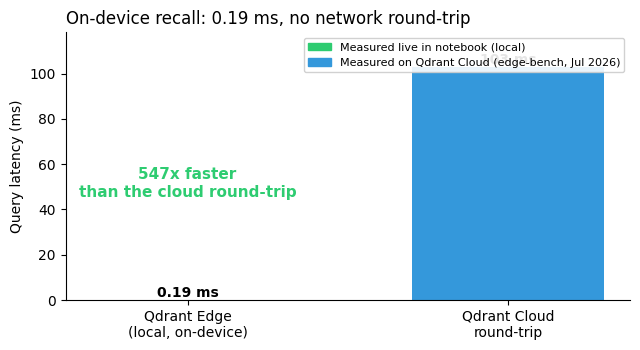

In [7]:
import numpy as np
from helper import latency_showdown, benchmark_query

# Grow to a realistic scale with filler vectors
# (content is irrelevant to latency).
rng = np.random.default_rng(0)
filler = rng.normal(size=(5000, NOMIC_DIM)).astype("float32")
shard.update(UpdateOperation.upsert_points([
    Point(
        id=1000 + i,
        vector={"text": filler[i].tolist()},
        payload={"kind": "filler"},
    )
    for i in range(len(filler))
]))
shard.optimize()
n = shard.info().points_count

median_ms = benchmark_query(
    shard, "text", embed_query("coffee"), runs=200
)
print(f"Local recall median at {n} memories: "
      f"{median_ms:.2f} ms over 200 queries")
# Cloud bar: real Qdrant Cloud query p50 from edge-bench
# (measured Jul 2026).
latency_showdown(median_ms, cloud_ms=102.8)

## 8. Money output: does the memory survive a restart?

⚠ Network disabled for this cell


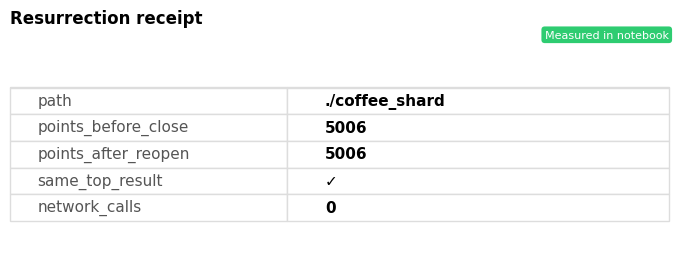

In [8]:
probe = QueryRequest(
    query=Query.Nearest(
        embed_query("coffee place outside"), using="text"
    ),
    limit=1, with_payload=True,
)

before_top = shard.query(probe)[0]
before_count = shard.info().points_count

shard.close()
del shard  # the in-memory object is gone

# Reopen and recall with the network blocked, so
# "network_calls: 0" is enforced, not asserted.
from helper import no_network, receipt_table

with no_network():
    reloaded = EdgeShard.load(SHARD_DIR)
    after_top = reloaded.query(probe)[0]

receipt_table([
    ("path", SHARD_DIR),
    ("points_before_close", before_count),
    ("points_after_reopen", reloaded.info().points_count),
    ("same_top_result",
     "✓" if before_top.id == after_top.id else "✗"),
    ("network_calls", 0),
])

In [9]:
# Cleanup: remove the shard directory so the notebook
# re-runs cleanly.
import shutil
reloaded.close()
shutil.rmtree(SHARD_DIR, ignore_errors=True)
print("Cleaned up", SHARD_DIR)

Cleaned up ./coffee_shard
